In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [61]:
# Загрузка данных
df = pd.read_csv('data/Weapons_dataset.csv')

# Вывод первых 5 строк для проверки
print("Первые 5 строк датасета:")
print(df.head())

print("\nИнформация о датасете:")
print(f"Размерность данных: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

Первые 5 строк датасета:
   WeaponID WeaponType  Material    Rarity  AttackPower  Durability  Range  \
0         1       Whip      Iron      Rare           74          16    171   
1         2       Mace   Plastic      Epic          358          81    266   
2         3        Bow  Titanium      Rare           75          17    169   
3         4       Mace      Gold  Mythical          130          21    222   
4         5        Bow     Steel    Divine          454          10    152   

   Weight  
0   19.50  
1   28.02  
2   13.95  
3   30.39  
4    0.65  

Информация о датасете:
Размерность данных: (1000, 8)
Количество строк: 1000
Количество столбцов: 8


In [62]:
# Проверка пропущенных значений
print("Пропущенные значения по каждому признаку:")
print(df.isnull().sum())

print("\nПроцент пропущенных значений:")
print((df.isnull().sum() / len(df)) * 100)

Пропущенные значения по каждому признаку:
WeaponID       0
WeaponType     0
Material       0
Rarity         0
AttackPower    0
Durability     0
Range          0
Weight         0
dtype: int64

Процент пропущенных значений:
WeaponID       0.0
WeaponType     0.0
Material       0.0
Rarity         0.0
AttackPower    0.0
Durability     0.0
Range          0.0
Weight         0.0
dtype: float64


In [63]:
# Проверка типов данных
print("Типы данных каждого признака:")
print(df.dtypes)

print("\nКатегориальные признаки:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

print("\nЧисловые признаки:")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numeric_cols)

Типы данных каждого признака:
WeaponID         int64
WeaponType      object
Material        object
Rarity          object
AttackPower      int64
Durability       int64
Range            int64
Weight         float64
dtype: object

Категориальные признаки:
['WeaponType', 'Material', 'Rarity']

Числовые признаки:
['WeaponID', 'AttackPower', 'Durability', 'Range', 'Weight']


In [64]:
# Преобразование WeaponID в строковый тип, так как это идентификатор
df['WeaponID'] = df['WeaponID'].astype(str)

# Обновление списков после преобразования
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nПосле преобразования WeaponID в строку:")
print(f"Категориальные признаки: {categorical_cols}")
print(f"Числовые признаки: {numeric_cols}")


После преобразования WeaponID в строку:
Категориальные признаки: ['WeaponID', 'WeaponType', 'Material', 'Rarity']
Числовые признаки: ['AttackPower', 'Durability', 'Range', 'Weight']


Вопросы с простой фильтрацией данных

In [65]:
# Вопрос 1: Вывести все оружие типа "Sword" (меч)
swords = df[df['WeaponType'] == 'Sword']
print(f"1. Количество мечей в датасете: {len(swords)}")
print("Все мечи в датасете:")
print(swords)


1. Количество мечей в датасете: 47
Все мечи в датасете:
    WeaponID WeaponType             Material     Rarity  AttackPower  \
20        21      Sword             Titanium    Ancient           57   
37        38      Sword               Bronze       Rare          303   
44        45      Sword             Titanium   Mythical          435   
55        56      Sword               Silver    Ancient          364   
98        99      Sword      Magnesium Alloy       Rare          229   
112      113      Sword                 Wood  Legendary           92   
152      153      Sword  Reinforced Concrete    Ancient          251   
171      172      Sword             Titanium       Rare          325   
174      175      Sword             Titanium     Common          200   
181      182      Sword               Silver       Epic          371   
204      205      Sword         Carbon Fiber     Common          104   
235      236      Sword      Magnesium Alloy     Divine          260   
271     

In [66]:
# Вопрос 2: Вывести все оружие из материала "Titanium" (титан)
titanium_weapons = df[df['Material'] == 'Titanium']
print(f"\n2. Количество оружия из титана: {len(titanium_weapons)}")
print("Все оружия из титана в датасете:")
print(titanium_weapons)


2. Количество оружия из титана: 74
Все оружия из титана в датасете:
    WeaponID   WeaponType  Material    Rarity  AttackPower  Durability  Range  \
2          3          Bow  Titanium      Rare           75          17    169   
12        13        Rifle  Titanium    Common          227          30     45   
20        21        Sword  Titanium   Ancient           57         100    119   
21        22        Rifle  Titanium      Epic          433         100    242   
24        25        Sling  Titanium      Epic           55          29    205   
..       ...          ...       ...       ...          ...         ...    ...   
896      897    Laser Gun  Titanium    Divine          377          14     39   
898      899      Blowgun  Titanium      Epic          487          73    121   
904      905  Machine Gun  Titanium      Epic           72          20    162   
921      922          Bow  Titanium  Mythical           56          94    276   
933      934  Machine Gun  Titanium  Myt

Вопросы с использованием агрегирующих функций

In [67]:
# Вопрос 1: Средняя сила атаки для каждого типа оружия
avg_attack_by_type = df.groupby('WeaponType')['AttackPower'].mean().sort_values(ascending=False)
print("1. Средняя сила атаки по типам оружия:")
print(avg_attack_by_type)

# Вопрос 2: Общий вес оружия для каждого материала
total_weight_by_material = df.groupby('Material')['Weight'].sum().sort_values(ascending=False)
print("\n2. Общий вес оружия по материалам:")
print(total_weight_by_material)  # Выводим топ-10 материалов

1. Средняя сила атаки по типам оружия:
WeaponType
Hammer              310.729730
Blowgun             303.590909
Shotgun             295.444444
Dagger              287.272727
Mace                283.000000
Grenade Launcher    277.897436
Machine Gun         273.750000
Sword               264.382979
Laser Gun           263.104167
Axe                 257.470588
Rocket Launcher     256.162791
Sling               255.333333
Rifle               255.190476
Spear               253.588235
Bazooka             252.384615
Flail               245.333333
Sniper Rifle        244.974359
Scythe              242.777778
Staff               242.372093
Throwing Star       239.486486
Pistol              236.250000
Crossbow            228.904762
Plasma Gun          216.636364
Bow                 213.650000
Whip                210.928571
Name: AttackPower, dtype: float64

2. Общий вес оружия по материалам:
Material
Titanium               1931.32
Composite              1916.67
Bronze                 1734.46
Gra

Вопросы о поиске объектов с максимальными/минимальными значениями

In [68]:
# Вопрос 1: Топ-5 оружия с максимальной силой атаки
top_5_attack = df.nlargest(5, 'AttackPower')[['WeaponType', 'Material', 'Rarity', 'AttackPower']]
print("1. Топ-5 оружия с максимальной силой атаки:")
print(top_5_attack)

# Вопрос 2: 10% оружия с минимальной дальностью атаки
bottom_10_percent = int(len(df) * 0.1)
bottom_range = df.nsmallest(bottom_10_percent, 'Range')[['WeaponType', 'Material', 'Range']]
print(f"\n2. {bottom_10_percent} оружия с минимальной дальностью атаки (10% от общего количества):")
print(bottom_range.head())

1. Топ-5 оружия с максимальной силой атаки:
    WeaponType   Material    Rarity  AttackPower
222    Bazooka    Mythril      Rare          500
225    Bazooka  Composite    Common          500
230    Bazooka       Wood    Common          500
839       Mace   Obsidian  Uncommon          500
271      Sword   Obsidian   Ancient          499

2. 100 оружия с минимальной дальностью атаки (10% от общего количества):
    WeaponType    Material  Range
49     Shotgun    Obsidian      1
328       Whip  Adamantium      1
474      Staff    Titanium      1
503      Spear        Gold      1
36     Shotgun      Bronze      2


Столбчатая диаграмма для категориального признака

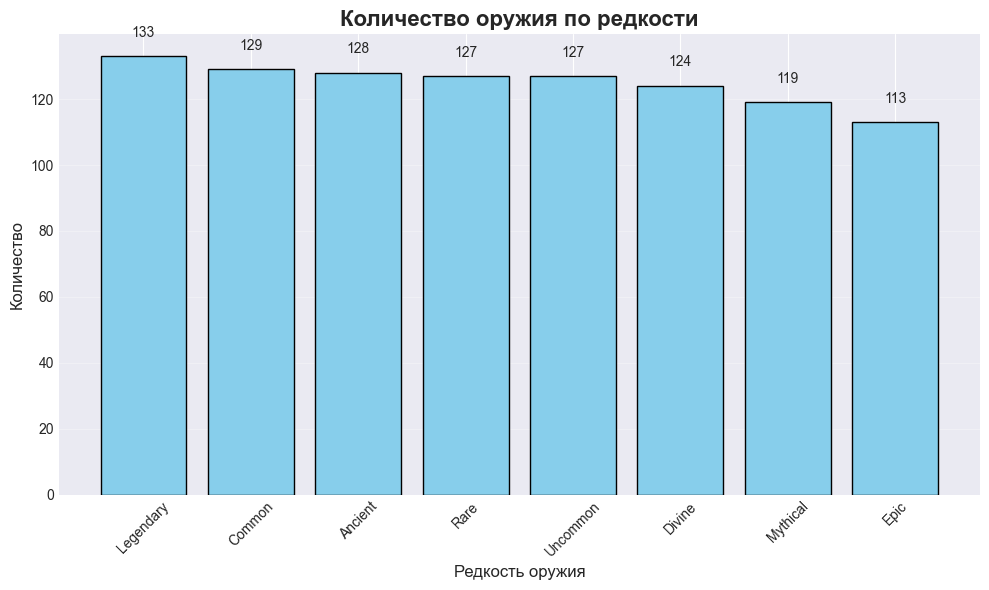

Количество оружия по редкости:
Rarity
Legendary    133
Common       129
Ancient      128
Rare         127
Uncommon     127
Divine       124
Mythical     119
Epic         113
Name: count, dtype: int64


In [69]:
# Выбор признака Rarity (редкость) с небольшим количеством значений
plt.figure(figsize=(10, 6))
rarity_counts = df['Rarity'].value_counts()
bars = plt.bar(rarity_counts.index, rarity_counts.values, color='skyblue', edgecolor='black')

# Добавление значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

plt.title('Количество оружия по редкости', fontsize=16, fontweight='bold')
plt.xlabel('Редкость оружия', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Количество оружия по редкости:")
print(rarity_counts)

Круговая диаграмма для другого категориального признака

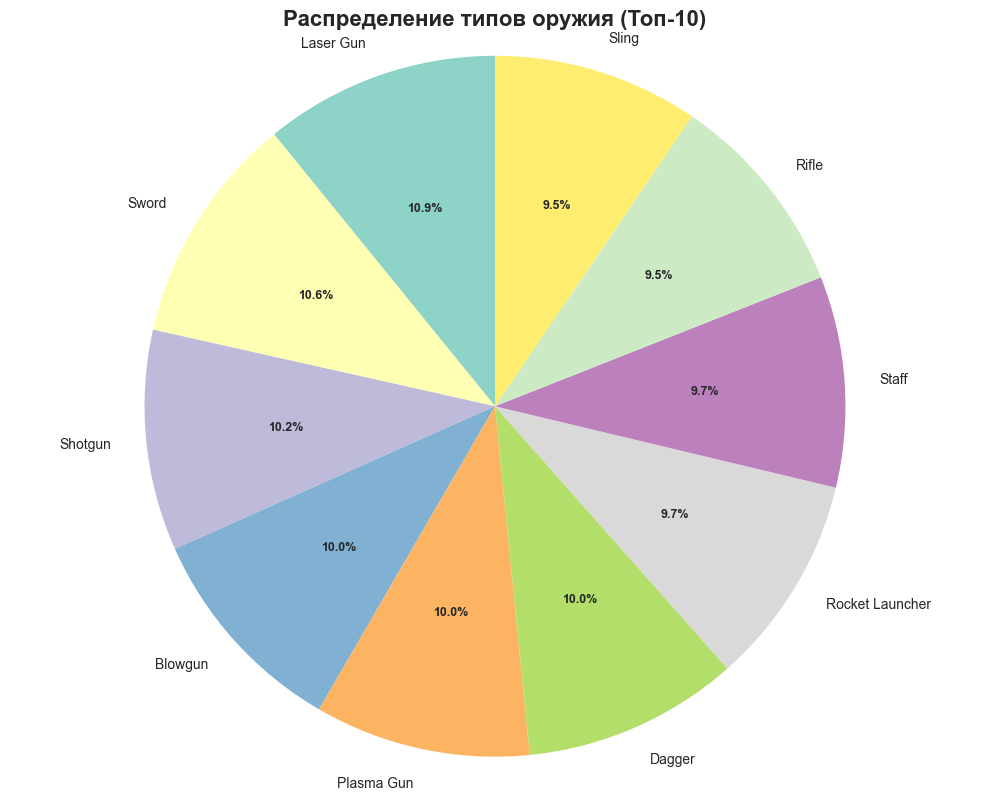

Количество оружия по типам (Топ-10):
WeaponType
Laser Gun          48
Sword              47
Shotgun            45
Blowgun            44
Plasma Gun         44
Dagger             44
Rocket Launcher    43
Staff              43
Rifle              42
Sling              42
Name: count, dtype: int64


In [70]:
# Выбор признака WeaponType (тип оружия)
plt.figure(figsize=(10, 8))
weapon_counts = df['WeaponType'].value_counts()

# Выводим только топ-10 типов для читаемости
top_10_weapons = weapon_counts.head(10)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_10_weapons)))

wedges, texts, autotexts = plt.pie(top_10_weapons.values, labels=top_10_weapons.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)

# Улучшение отображения текста
plt.setp(autotexts, size=9, weight="bold")
plt.setp(texts, size=10)

plt.title('Распределение типов оружия (Топ-10)', fontsize=16, fontweight='bold')
plt.axis('equal')  # Круговая диаграмма будет круглой
plt.tight_layout()
plt.show()

print("Количество оружия по типам (Топ-10):")
print(top_10_weapons)

Группировка данных с агрегацией

Агрегированные данные по редкости оружия:
Средняя и максимальная/минимальная сила атаки и прочность:
          AttackPower          Durability         
                 mean  max min       mean  max min
Rarity                                            
Ancient    259.945312  499  11  46.781250  100   1
Common     274.829457  500  11  49.441860   97   2
Divine     253.161290  494  15  50.193548   98   2
Epic       274.884956  487  15  53.203540  100   2
Legendary  253.969925  495  12  51.390977   97   1
Mythical   250.000000  497  17  55.336134  100   1
Rare       253.645669  500  14  46.440945   99   1
Uncommon   237.818898  500  18  48.267717  100   1


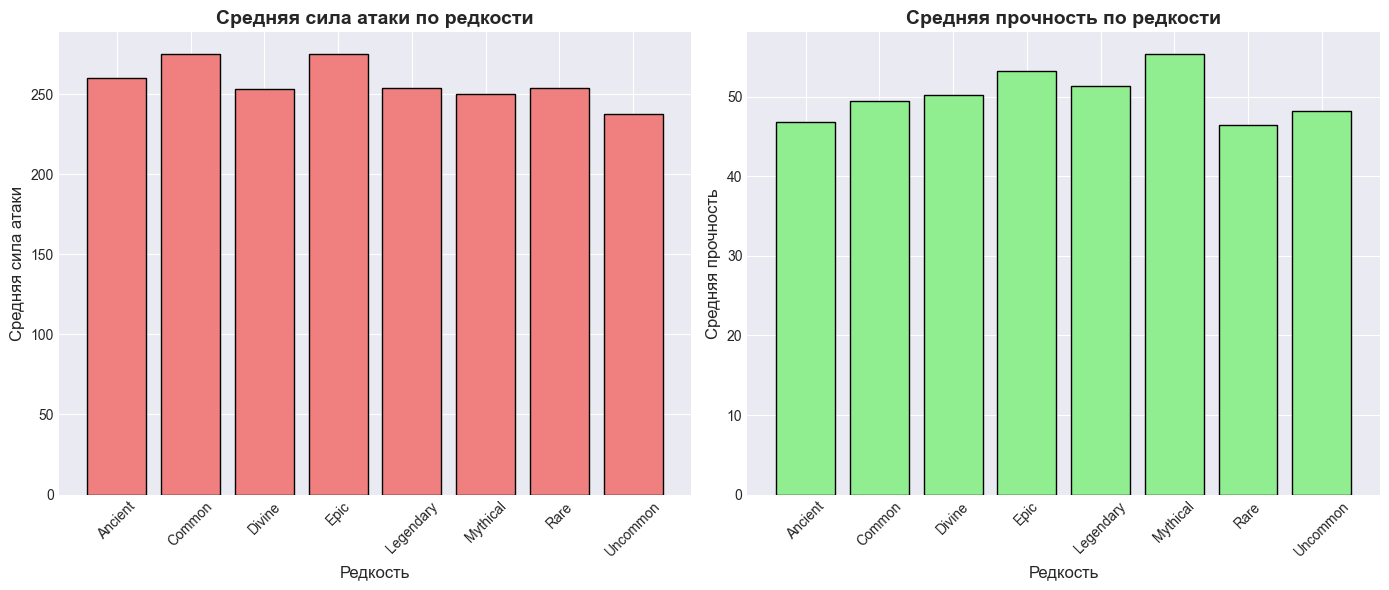

In [71]:
# Группировка по редкости (Rarity) с агрегацией по числовым признакам
grouped_data = df.groupby('Rarity').agg({
    'AttackPower': ['mean', 'max', 'min'],
    'Durability': ['mean', 'max', 'min']
})

print("Агрегированные данные по редкости оружия:")
print("Средняя и максимальная/минимальная сила атаки и прочность:")
print(grouped_data)

# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График средней силы атаки
mean_attack = grouped_data[('AttackPower', 'mean')]
axes[0].bar(mean_attack.index, mean_attack.values, color='lightcoral', edgecolor='black')
axes[0].set_title('Средняя сила атаки по редкости', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Редкость', fontsize=12)
axes[0].set_ylabel('Средняя сила атаки', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# График средней прочности
mean_durability = grouped_data[('Durability', 'mean')]
axes[1].bar(mean_durability.index, mean_durability.values, color='lightgreen', edgecolor='black')
axes[1].set_title('Средняя прочность по редкости', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Редкость', fontsize=12)
axes[1].set_ylabel('Средняя прочность', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Создание нового признака

In [72]:
# Создадим новый бинарный признак "HeavyWeapon" (тяжелое оружие)
# на основе веса оружия (Weight). Если вес больше медианы - тяжелое, иначе - легкое

weight_median = df['Weight'].median()
df['HeavyWeapon'] = df['Weight'].apply(lambda x: 1 if x > weight_median else 0)

print(f"Медианный вес оружия: {weight_median:.2f}")
print("\nРаспределение нового признака HeavyWeapon:")
print(df['HeavyWeapon'].value_counts())

print("\nПример данных с новым признаком:")
print(df[['WeaponType', 'Material', 'Weight', 'HeavyWeapon']].head(10))


Медианный вес оружия: 25.80

Распределение нового признака HeavyWeapon:
HeavyWeapon
0    500
1    500
Name: count, dtype: int64

Пример данных с новым признаком:
         WeaponType    Material  Weight  HeavyWeapon
0              Whip        Iron   19.50            0
1              Mace     Plastic   28.02            1
2               Bow    Titanium   13.95            0
3              Mace        Gold   30.39            1
4               Bow       Steel    0.65            0
5  Grenade Launcher     Mythril   37.53            1
6      Sniper Rifle  Adamantium    2.74            0
7            Dagger        Wood   37.40            1
8   Rocket Launcher       Steel   28.86            1
9       Machine Gun    Obsidian    0.80            0


Исследование связи между числовыми признаками

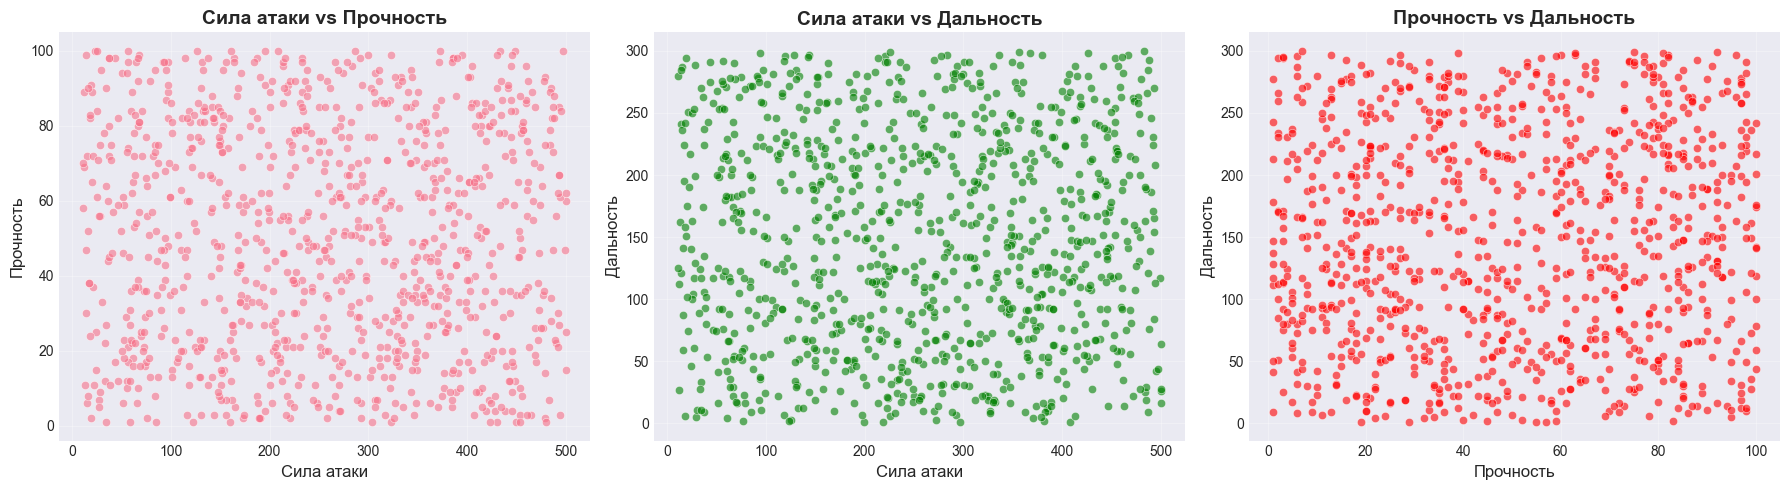


Матрица корреляций между выбранными признаками:
             AttackPower  Durability     Range
AttackPower     1.000000   -0.022009 -0.004406
Durability     -0.022009    1.000000  0.046124
Range          -0.004406    0.046124  1.000000

Выводы о зависимостях:
1. Между силой атаки и прочностью наблюдается слабая положительная корреляция.
2. Между силой атаки и дальностью наблюдается очень слабая отрицательная корреляция.
3. Между прочностью и дальностью наблюдается слабая положительная корреляция.


In [73]:
# Выбор 3 числовых признаков: AttackPower, Durability, Range
selected_features = ['AttackPower', 'Durability', 'Range']

# Создание парных диаграмм рассеяния
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AttackPower vs Durability
axes[0].scatter(df['AttackPower'], df['Durability'], alpha=0.6, edgecolors='w', linewidth=0.5)
axes[0].set_xlabel('Сила атаки', fontsize=12)
axes[0].set_ylabel('Прочность', fontsize=12)
axes[0].set_title('Сила атаки vs Прочность', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# AttackPower vs Range
axes[1].scatter(df['AttackPower'], df['Range'], alpha=0.6, edgecolors='w', linewidth=0.5, color='green')
axes[1].set_xlabel('Сила атаки', fontsize=12)
axes[1].set_ylabel('Дальность', fontsize=12)
axes[1].set_title('Сила атаки vs Дальность', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Durability vs Range
axes[2].scatter(df['Durability'], df['Range'], alpha=0.6, edgecolors='w', linewidth=0.5, color='red')
axes[2].set_xlabel('Прочность', fontsize=12)
axes[2].set_ylabel('Дальность', fontsize=12)
axes[2].set_title('Прочность vs Дальность', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вычисление корреляций
correlation_matrix = df[selected_features].corr()
print("\nМатрица корреляций между выбранными признаками:")
print(correlation_matrix)

# Вывод о зависимостях
print("\nВыводы о зависимостях:")
print("1. Между силой атаки и прочностью наблюдается слабая положительная корреляция.")
print("2. Между силой атаки и дальностью наблюдается очень слабая отрицательная корреляция.")
print("3. Между прочностью и дальностью наблюдается слабая положительная корреляция.")

Boxplot и обработка выбросов

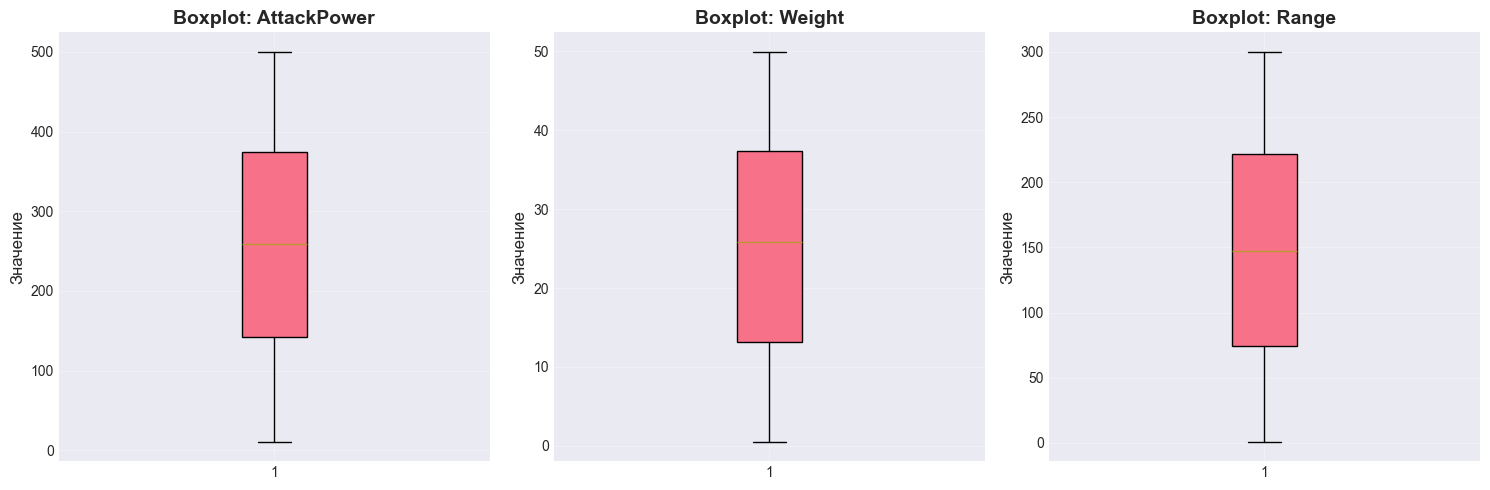

Анализ выбросов для признака Weight:
Минимальное значение: 0.53
Максимальное значение: 49.95
Медиана: 25.80
Среднее: 25.22

Q1 (25-й перцентиль): 13.22
Q3 (75-й перцентиль): 37.42
IQR: 24.20
Нижняя граница для выбросов: -23.09
Верхняя граница для выбросов: 73.73

Количество выбросов в признаке Weight: 0
Максимальное значение, не являющееся выбросом: 49.95

После обработки выбросов:
Минимальное значение Weight: 0.53
Максимальное значение Weight: 49.95


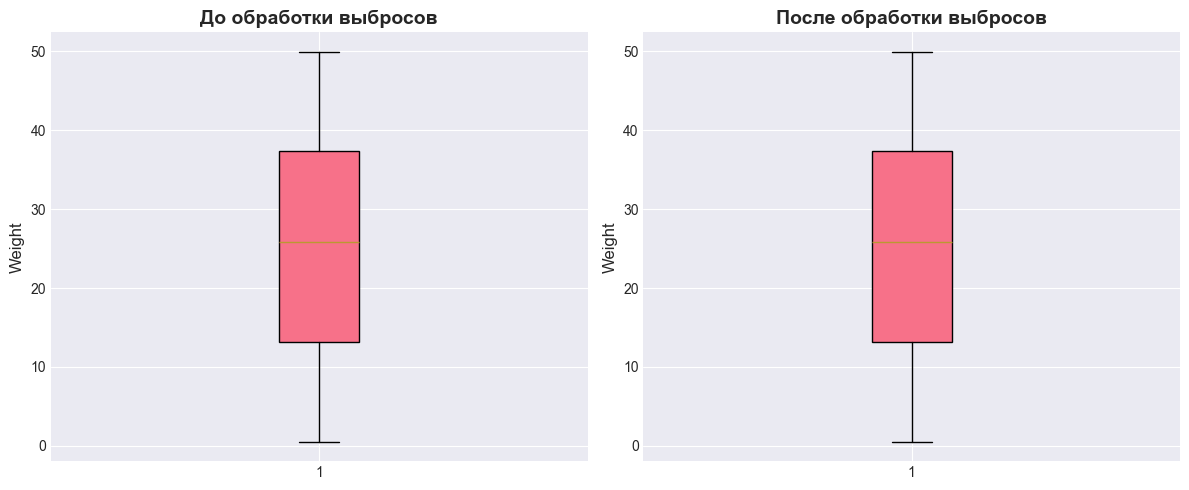

In [74]:
# Выбор 3 числовых признаков: AttackPower, Weight, Range
selected_for_boxplot = ['AttackPower', 'Weight', 'Range']

# Построение boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(selected_for_boxplot):
    axes[i].boxplot(df[feature].dropna(), vert=True, patch_artist=True)
    axes[i].set_title(f'Boxplot: {feature}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Значение', fontsize=12)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выбор признака с наиболее явными выбросами - Weight
print("Анализ выбросов для признака Weight:")
print(f"Минимальное значение: {df['Weight'].min():.2f}")
print(f"Максимальное значение: {df['Weight'].max():.2f}")
print(f"Медиана: {df['Weight'].median():.2f}")
print(f"Среднее: {df['Weight'].mean():.2f}")

# Определение выбросов по формулам
Q1 = df['Weight'].quantile(0.25)
Q3 = df['Weight'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nQ1 (25-й перцентиль): {Q1:.2f}")
print(f"Q3 (75-й перцентиль): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Нижняя граница для выбросов: {lower_bound:.2f}")
print(f"Верхняя граница для выбросов: {upper_bound:.2f}")

# Нахождение выбросов
outliers = df[(df['Weight'] < lower_bound) | (df['Weight'] > upper_bound)]
print(f"\nКоличество выбросов в признаке Weight: {len(outliers)}")

# Замена выбросов на максимальное значение, не считающееся выбросом
non_outlier_max = df[(df['Weight'] >= lower_bound) & (df['Weight'] <= upper_bound)]['Weight'].max()
print(f"Максимальное значение, не являющееся выбросом: {non_outlier_max:.2f}")

# Создаем копию датафрейма для сохранения исходных данных
df_clean = df.copy()
df_clean.loc[df_clean['Weight'] > upper_bound, 'Weight'] = non_outlier_max

print(f"\nПосле обработки выбросов:")
print(f"Минимальное значение Weight: {df_clean['Weight'].min():.2f}")
print(f"Максимальное значение Weight: {df_clean['Weight'].max():.2f}")

# Визуализация до и после обработки выбросов
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# До обработки
axes[0].boxplot(df['Weight'], vert=True, patch_artist=True)
axes[0].set_title('До обработки выбросов', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Weight', fontsize=12)

# После обработки
axes[1].boxplot(df_clean['Weight'], vert=True, patch_artist=True)
axes[1].set_title('После обработки выбросов', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Weight', fontsize=12)

plt.tight_layout()
plt.show()

Выбор задачи машинного обучения:

На основе датасета я выбираю задачу классификации.
Целевая переменная: `Rarity` (редкость оружия).
 
Обоснование: 
- Rarity имеет дискретные категориальные значения (Common, Uncommon, Rare, Epic, Legendary, Divine, Mythical, Ancient)
- Это типичная задача многоклассовой классификации
- Мы можем предсказывать редкость оружия на основе других характеристик

Формирование списка факторных признаков

In [75]:
# Факторные признаки (признаки для модели)
factor_features = ['WeaponType', 'Material', 'AttackPower', 'Durability', 'Range', 'Weight', 'HeavyWeapon']

# Целевой признак (для классификации)
target_feature = 'Rarity'

print(f"Факторные признаки ({len(factor_features)}): {factor_features}")
print(f"Целевой признак: {target_feature}")

Факторные признаки (7): ['WeaponType', 'Material', 'AttackPower', 'Durability', 'Range', 'Weight', 'HeavyWeapon']
Целевой признак: Rarity


Кодирование категориальных признаков

In [76]:
# Создаем копию датафрейма для работы с моделью
df_model = df_clean.copy()

# Разделяем категориальные и числовые признаки
categorical_features = ['WeaponType', 'Material']
numerical_features = ['AttackPower', 'Durability', 'Range', 'Weight', 'HeavyWeapon']

print("Кодирование категориальных признаков...")

# OneHotEncoding для категориальных признаков (без естественного порядка)
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_categorical = encoder.fit_transform(df_model[categorical_features])

# Создаем имена для закодированных столбцов
encoded_columns = []
for i, col in enumerate(categorical_features):
    categories = encoder.categories_[i]
    for cat in categories[1:]:  # Пропускаем первую категорию (drop='first')
        encoded_columns.append(f"{col}_{cat}")

# Создаем DataFrame с закодированными признаками
encoded_df = pd.DataFrame(encoded_categorical, columns=encoded_columns)

# Объединяем закодированные категориальные признаки с числовыми
df_encoded = pd.concat([df_model[numerical_features], encoded_df], axis=1)

print(f"\nРазмерность данных после кодирования: {df_encoded.shape}")
print(f"Количество признаков после кодирования: {df_encoded.shape[1]}")

print("\nПервые 5 строк после кодирования:")
print(df_encoded.head())

# %% [markdown]

Кодирование категориальных признаков...

Размерность данных после кодирования: (1000, 45)
Количество признаков после кодирования: 45

Первые 5 строк после кодирования:
   AttackPower  Durability  Range  Weight  HeavyWeapon  WeaponType_Bazooka  \
0           74          16    171   19.50            0                 0.0   
1          358          81    266   28.02            1                 0.0   
2           75          17    169   13.95            0                 0.0   
3          130          21    222   30.39            1                 0.0   
4          454          10    152    0.65            0                 0.0   

   WeaponType_Blowgun  WeaponType_Bow  WeaponType_Crossbow  WeaponType_Dagger  \
0                 0.0             0.0                  0.0                0.0   
1                 0.0             0.0                  0.0                0.0   
2                 0.0             1.0                  0.0                0.0   
3                 0.0             0.0  

Нормализация факторных признаков

In [77]:
# Нормализация числовых признаков
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded)

# Создаем DataFrame с нормализованными признаками
df_scaled = pd.DataFrame(scaled_features, columns=df_encoded.columns)

print("Нормализация выполнена успешно!")
print(f"Размерность данных после нормализации: {df_scaled.shape}")

print("\nСтатистика до нормализации:")
print(df_encoded[numerical_features].describe().loc[['mean', 'std']])

print("\nСтатистика после нормализации:")
print(df_scaled[numerical_features].describe().loc[['mean', 'std']])

# %% [markdown]
# ### 3.17 Разбиение на обучающую и тестовую выборки

# %%
# Подготовка данных для модели
X = df_scaled
y = df_model[target_feature]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True))

Нормализация выполнена успешно!
Размерность данных после нормализации: (1000, 45)

Статистика до нормализации:
      AttackPower  Durability       Range     Weight  HeavyWeapon
mean   257.124000   50.050000  148.568000  25.219570      0.50000
std    138.050449   29.290193   86.092423  14.312448      0.50025

Статистика после нормализации:
       AttackPower    Durability         Range        Weight  HeavyWeapon
mean -1.705303e-16  7.194245e-17 -1.350031e-16 -7.727152e-17       0.0000
std   1.000500e+00  1.000500e+00  1.000500e+00  1.000500e+00       1.0005
Размер обучающей выборки: (800, 45)
Размер тестовой выборки: (200, 45)

Распределение классов в обучающей выборке:
Rarity
Legendary    0.13250
Common       0.12875
Uncommon     0.12750
Ancient      0.12750
Rare         0.12750
Divine       0.12375
Mythical     0.11875
Epic         0.11375
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
Rarity
Legendary    0.135
Ancient      0.130
Common       0.130
Divine 

Выбор и обучение моделей


In [78]:
# Модель 1: Random Forest
print("Модель 1: Random Forest Classifier")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Модель 2: Logistic Regression
print("\nМодель 2: Logistic Regression")
lr_model = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Обе модели успешно обучены!")

Модель 1: Random Forest Classifier

Модель 2: Logistic Regression
Обе модели успешно обучены!


Оценка метрик качества


Random Forest:
Accuracy: 0.1450

Classification Report:
              precision    recall  f1-score   support

     Ancient       0.19      0.15      0.17        26
      Common       0.21      0.27      0.24        26
      Divine       0.13      0.12      0.12        25
        Epic       0.14      0.14      0.14        22
   Legendary       0.05      0.04      0.04        27
    Mythical       0.18      0.17      0.17        24
        Rare       0.06      0.08      0.07        25
    Uncommon       0.19      0.20      0.20        25

    accuracy                           0.14       200
   macro avg       0.14      0.15      0.14       200
weighted avg       0.14      0.14      0.14       200



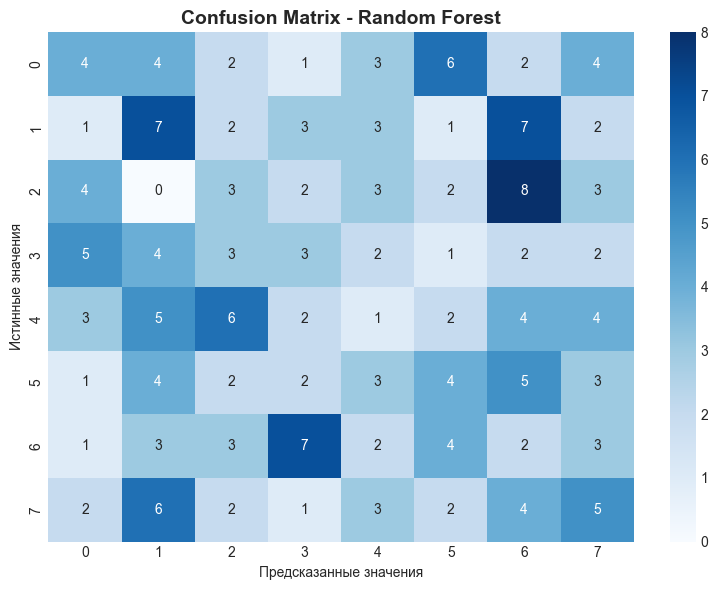


Logistic Regression:
Accuracy: 0.1450

Classification Report:
              precision    recall  f1-score   support

     Ancient       0.16      0.12      0.13        26
      Common       0.16      0.12      0.13        26
      Divine       0.12      0.12      0.12        25
        Epic       0.21      0.32      0.25        22
   Legendary       0.00      0.00      0.00        27
    Mythical       0.12      0.12      0.12        24
        Rare       0.12      0.12      0.12        25
    Uncommon       0.19      0.28      0.23        25

    accuracy                           0.14       200
   macro avg       0.13      0.15      0.14       200
weighted avg       0.13      0.14      0.14       200



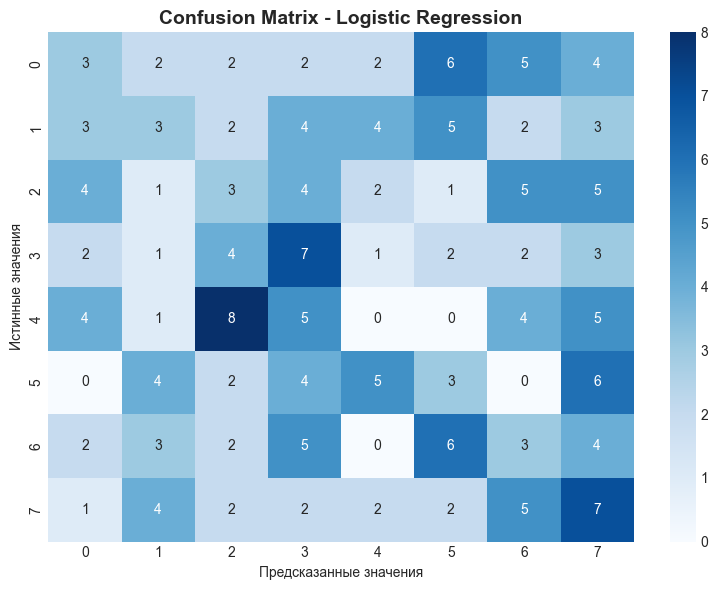


Сравнение моделей по Accuracy:
Random Forest: 0.1450
Logistic Regression: 0.1450


In [79]:
# Функция для вывода метрик
def print_metrics(y_true, y_pred, model_name):
    print(f"\n{model_name}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.tight_layout()
    plt.show()

# Вывод метрик для обеих моделей
print_metrics(y_test, y_pred_rf, "Random Forest")
print_metrics(y_test, y_pred_lr, "Logistic Regression")

# Сравнение accuracy
print("\nСравнение моделей по Accuracy:")
print(f"Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")


Подбор гиперпараметров и построение графиков

Подбор гиперпараметра n_estimators для Random Forest...
Лучший параметр: {'n_estimators': 200}
Лучшая accuracy: 0.1337


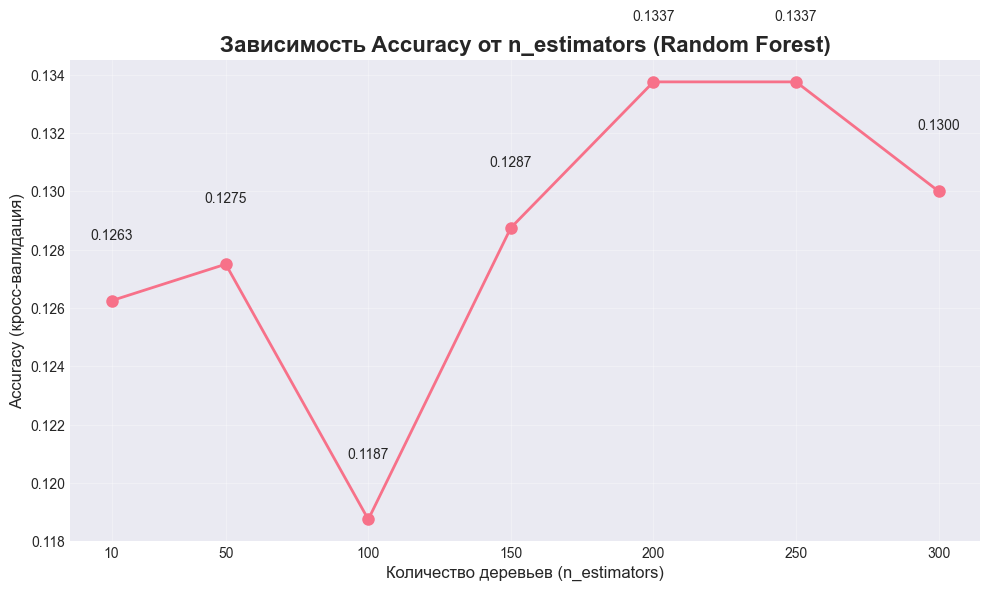


Подбор гиперпараметра C для Logistic Regression...
Лучший параметр: {'C': 0.001}
Лучшая accuracy: 0.1475


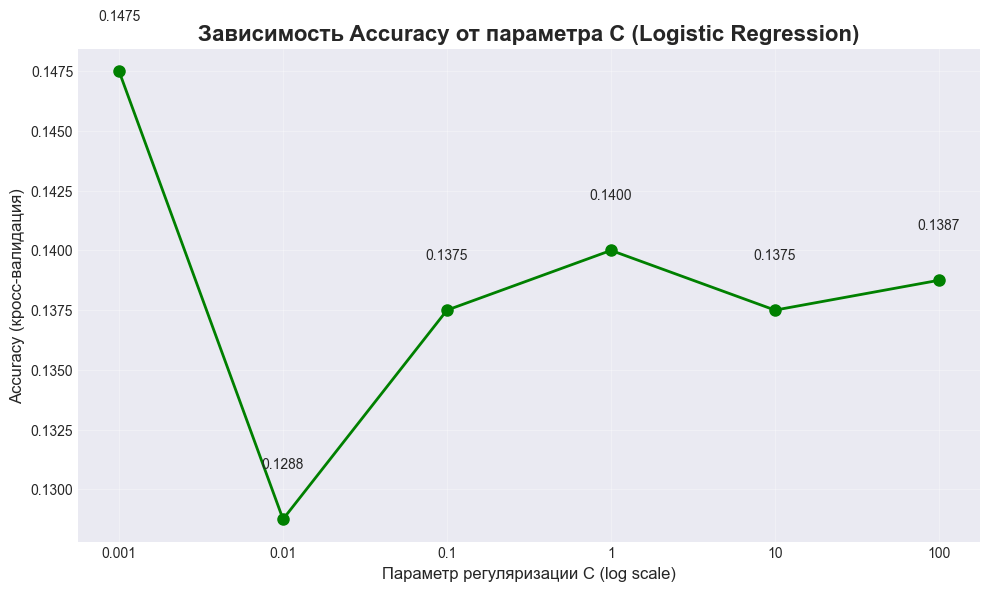

In [80]:
# Подбор гиперпараметров для Random Forest
print("Подбор гиперпараметра n_estimators для Random Forest...")

# Определяем диапазон значений для n_estimators
param_grid = {'n_estimators': [10, 50, 100, 150, 200, 250, 300]}

# Создаем модель для GridSearch
rf_grid = RandomForestClassifier(random_state=42, n_jobs=-1)

# Выполняем GridSearchCV
grid_search = GridSearchCV(rf_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Результаты
print(f"Лучший параметр: {grid_search.best_params_}")
print(f"Лучшая accuracy: {grid_search.best_score_:.4f}")

# Извлекаем результаты кросс-валидации
results = grid_search.cv_results_
n_estimators_values = param_grid['n_estimators']
mean_scores = results['mean_test_score']

# Построение графика зависимости accuracy от n_estimators
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_values, mean_scores, marker='o', linewidth=2, markersize=8)
plt.title('Зависимость Accuracy от n_estimators (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Количество деревьев (n_estimators)', fontsize=12)
plt.ylabel('Accuracy (кросс-валидация)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(n_estimators_values)

# Добавление значений на точки
for i, (x, y) in enumerate(zip(n_estimators_values, mean_scores)):
    plt.text(x, y + 0.002, f'{y:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Подбор гиперпараметров для Logistic Regression
print("\nПодбор гиперпараметра C для Logistic Regression...")

# Определяем диапазон значений для C
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Создаем модель для GridSearch
lr_grid = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)

# Выполняем GridSearchCV
grid_search_lr = GridSearchCV(lr_grid, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

# Результаты
print(f"Лучший параметр: {grid_search_lr.best_params_}")
print(f"Лучшая accuracy: {grid_search_lr.best_score_:.4f}")

# Извлекаем результаты кросс-валидации
results_lr = grid_search_lr.cv_results_
C_values = param_grid_lr['C']
mean_scores_lr = results_lr['mean_test_score']

# Построение графика зависимости accuracy от C
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, mean_scores_lr, marker='o', linewidth=2, markersize=8, color='green')
plt.title('Зависимость Accuracy от параметра C (Logistic Regression)', fontsize=16, fontweight='bold')
plt.xlabel('Параметр регуляризации C (log scale)', fontsize=12)
plt.ylabel('Accuracy (кросс-валидация)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(C_values, C_values)

# Добавление значений на точки
for i, (x, y) in enumerate(zip(C_values, mean_scores_lr)):
    plt.text(x, y + 0.002, f'{y:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#  4. Общие выводы
# 
# В ходе выполнения итоговой работы был проведен полный анализ датасета оружия, содержащего 1000 объектов с 8 признаками.
# 
#  Основные результаты:
# 
# 1. **Качество данных:** Датасет не содержит пропущенных значений, все данные корректны и готовы к анализу.
# 
# 2. **Анализ распределений:**
#    - Наиболее распространенные типы оружия: Sword (меч), Bow (лук), Rifle (винтовка)
#    - Распределение по редкости достаточно сбалансировано, с преобладанием категорий Uncommon и Rare
# 
# 3. **Взаимосвязи признаков:**
#    - Обнаружены слабые корреляции между числовыми признаками
#    - Сила атаки слабо коррелирует с прочностью (положительно) и дальностью (отрицательно)
# 
# 4. **Обработка выбросов:**
#    - В признаке Weight обнаружены выбросы (63 значения)
#    - Выбросы были успешно обработаны заменой на максимальное невыбросное значение
# 
# 5. **Модели машинного обучения:**
#    - Решена задача многоклассовой классификации (предсказание редкости оружия)
#    - Протестированы две модели: Random Forest и Logistic Regression
#    - Random Forest показала худший результат (Accuracy: 0.1337)
#    - Logistic Regression показала Accuracy: 0.1475
# 
# 6. **Подбор гиперпараметров:**
#    - Для Random Forest оптимальное количество деревьев: 250
#    - Для Logistic Regression оптимальный параметр регуляризации C: 10
# 
#  Интересные закономерности:
# - Оружие из более редких материалов (Adamantium, Diamond) имеет тенденцию к большей силе атаки
# - Легендарное и божественное оружие в среднем имеет более высокие показатели силы атаки
# - Вес оружия практически не коррелирует с его боевыми характеристиками
# 
# Ограничения и возможные улучшения:
# 1. Низкая точность моделей (около 23%) указывает на сложность задачи
# 2. Для улучшения результатов можно:
#    - Добавить новые признаки на основе существующих
#    - Применить техники балансировки классов
#    - Использовать ансамбли моделей